In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Класс среды

In [ ]:
class DroneNavEnvV1:
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

        # Границы пространства
        self.x_min, self.x_max = 0.0, 24.0
        self.y_min, self.y_max = 0.0, 12.0

        # Станция
        self.station_cx, self.station_cy = 21.5, 8.5
        self.station_r = 0.9
        self.p_charge = 0.025

        # Старт
        self.start_mu = (3.5, 6.0)
        self.start_sigma = 1.8
        self.start_clip_x = (1.0, 7.0)
        self.start_clip_y = (2.0, 10.0)

        # Ветер
        self.wind_low, self.wind_high = -0.11, 0.11
        self.wind_period = 15

        # Препятствия
        self.obstacles = [
            (10.0, 2.0, 11.5, 5.5),
            (13.0, 7.0, 14.5, 10.0),
            (16.5, 3.5, 18.0, 6.5),
            (19.0, 9.0, 20.5, 11.5),
        ]

        # Скорости
        self.speeds = [0.10, 0.25, 0.40, 0.60]

        # 16 действий = 4 направления x 4 скорости
        self.dir_vectors = [
            (1.0, 0.0),   # вправо
            (0.0, 1.0),   # вверх
            (-1.0, 0.0),  # влево
            (0.0, -1.0),  # вниз
        ]

        self.actions = []
        for d in range(4):
            for sp in self.speeds:
                self.actions.append((d, sp))
        self.n_actions = len(self.actions)  # 16

        # Дискретизация состояния: 14 x 14 x 12 x 4
        self.n_dx = 14 # dx делится на 14 зон
        self.n_dy = 14 # dy делится на 14 зон
        self.n_b = 12 # b делится на 12 уровней
        self.n_v = 4 # v имеет 4 возможных значения
        self.n_states = self.n_dx * self.n_dy * self.n_b * self.n_v

        # Максимальные и минимальные смещения (за счёт ограничения среды) отностительно станции с учётом знака (направления)
        self.dx_min = self.station_cx - self.x_max
        self.dx_max = self.station_cx - self.x_min
        self.dy_min = self.station_cy - self.y_max
        self.dy_max = self.station_cy - self.y_min

        self.reset()

    # ограничивает число диапазоном [low, high], для ограничений координат дрона
    def _clip(self, value, low, high):
        return max(low, min(high, value))

    def _in_station(self, x, y):
        return (x - self.station_cx) ** 2 + (y - self.station_cy) ** 2 < self.station_r ** 2

    # пересекает ли отрезок от (x0, y0) до (x1, y1) прямоугольник с углами (rx0, ry0) ЛН и (rx1, ry1) ВП.
    def _segment_intersects_rect(self, x0, y0, x1, y1, rx0, ry0, rx1, ry1):
       # x(t) = x0 + t * dx, y(t) = y0 + t * dy
        dx = x1 - x0
        dy = y1 - y0
        t0, t1 = 0.0, 1.0 # рассматриваем всё перемещение дрона

        # принимает ограничения только в одном стандартном виде p * t <= q
        def clip(p, q, t0, t1):
            if p == 0.0:
                if q < 0.0:
                    return False, t0, t1
                return True, t0, t1

            r = q / p
            if p < 0.0:
                if r > t1:
                    return False, t0, t1
                if r > t0:
                    t0 = r
            else:
                if r < t0:
                    return False, t0, t1
                if r < t1:
                    t1 = r
            return True, t0, t1

        ok, t0, t1 = clip(-dx, x0 - rx0, t0, t1)
        if not ok:
            return False
        ok, t0, t1 = clip(dx, rx1 - x0, t0, t1)
        if not ok:
            return False
        ok, t0, t1 = clip(-dy, y0 - ry0, t0, t1)
        if not ok:
            return False
        ok, t0, t1 = clip(dy, ry1 - y0, t0, t1)
        if not ok:
            return False
        return True

    def _collides(self, x0, y0, x1, y1):
        # Перебор прямогульных препятствий (ox0, oy0, ox1, oy1) ox0, oy0 - левый нижний, ox1, oy1 - правый верхний углы
        for (ox0, oy0, ox1, oy1) in self.obstacles:
            # Проверяется, пересекает ли отрезок движения дрона (из одной точки в другую) прямоугольник-препятствие (x0, y0)  -------->  (x1, y1)
            if self._segment_intersects_rect(x0, y0, x1, y1, ox0, oy0, ox1, oy1):
                return True
        return False

    # value число, которое надо дискретизировать
    # vmin минимальное возможное значение
    # n_bins количество ячеек
    def _bin_index(self, value, vmin, vmax, n_bins):
        if value <= vmin:
            return 0
        if value >= vmax:
            return n_bins - 1

        frac = (value - vmin) / (vmax - vmin) # доля положения внутри диапазона
        idx = int(frac * n_bins) # определяем номер ячейки

        if idx < 0:
            return 0
        if idx >= n_bins:
            return n_bins - 1
        return idx

    # Ангенту нужно одно и то же состояние - всегда один и тот же индекс, разные состояния - разные индексы
    def _state_to_index(self, dx_bin, dy_bin, b_bin, v_idx):
        return (((dx_bin * self.n_dy + dy_bin) * self.n_b + b_bin) * self.n_v + v_idx) # уникальный индекс в Q таблице на основе 4 дискретных состояний

    def discretize(self, x, y, b, v):
        # Смещение до станции
        dx = self.station_cx - x
        dy = self.station_cy - y

        dx_bin = self._bin_index(dx, self.dx_min, self.dx_max, self.n_dx)
        dy_bin = self._bin_index(dy, self.dy_min, self.dy_max, self.n_dy)
        b_bin = self._bin_index(b, 0.0, 1.0, self.n_b)
        v_idx = self.speeds.index(v)

        s_idx = self._state_to_index(dx_bin, dy_bin, b_bin, v_idx)
        return s_idx, (dx_bin, dy_bin, b_bin, v_idx)

    # метод начинает начинает новый эпизод среды, возвращает начальное состояние эпизода
    def reset(self):
        # x берётся из нормального распределения вокруг 3.5
        x = self.rng.normal(self.start_mu[0], self.start_sigma)
        y = self.rng.normal(self.start_mu[1], self.start_sigma)

        x = self._clip(x, self.start_clip_x[0], self.start_clip_x[1])
        y = self._clip(y, self.start_clip_y[0], self.start_clip_y[1])

        self.x = x
        self.y = y
        self.b = 1.0
        self.v = 0.25
        self.t = 0 # Обнуляется счётчик шагов эпизода.

        # Задаётся начальный ветер.
        self.wx = self.rng.uniform(self.wind_low, self.wind_high)
        self.wy = self.rng.uniform(self.wind_low, self.wind_high)

        s_idx, _ = self.discretize(self.x, self.y, self.b, self.v)
        return s_idx

    # выполняет один шаг среды
    def step(self, action_idx):
        # Обновление ветра каждые 15 шагов
        if self.t > 0 and (self.t % self.wind_period == 0):
            self.wx = self.rng.uniform(self.wind_low, self.wind_high)
            self.wy = self.rng.uniform(self.wind_low, self.wind_high)

        d, v_cmd = self.actions[action_idx]
        ux, uy = self.dir_vectors[d]

        # запоминаем старую позицию
        x0, y0 = self.x, self.y

        # шаг выполняется сразу на выбранной скорости действия
        x1 = x0 + v_cmd * ux + self.wx
        y1 = y0 + v_cmd * uy + self.wy

        # ограничение координат дрона картой
        x1 = self._clip(x1, self.x_min, self.x_max)
        y1 = self._clip(y1, self.y_min, self.y_max)

        collision = False
        if self._collides(x0, y0, x1, y1):
            collision = True
            x1, y1 = x0, y0   # запрет входа

        in_station = self._in_station(x1, y1)
        Istation = 1.0 if in_station else 0.0

        # квадрат нормы ветра ||w||^2
        w2 = self.wx * self.wx + self.wy * self.wy

        # Расход батареи
        b1 = self.b - 0.018 * (v_cmd ** 2) - 0.003 * w2 - 0.002 * abs(v_cmd) + Istation * self.p_charge
        if b1 > 1.0:
            b1 = 1.0

        # Награда варианта 1
        base_r = -1.0 - 0.030 * (v_cmd ** 2) + 0.12 * self.p_charge * Istation

        self.t += 1 # добавляем шаг эпизода

        # терминальные условия проверяются после выполнения действия и обновления состояния
        done = False
        success = False
        reward = base_r

        if b1 < 0.04:
            done = True
            reward = -170.0
        else:
            if in_station and (b1 > 0.90) and (self.t <= 140):
                done = True
                success = True
                reward = 90.0
            elif self.t >= 200:
                done = True
                reward = base_r

        # После шага наблюдаемая скорость становится выбранной
        self.x, self.y, self.b, self.v = x1, y1, b1, v_cmd

        s_idx, s_bins = self.discretize(self.x, self.y, self.b, self.v)

        info = {
            "t": self.t,
            "x": self.x,
            "y": self.y,
            "b": self.b,
            "v": self.v,
            "wx": self.wx,
            "wy": self.wy,
            "collision": collision,
            "success": success,
            "in_station": in_station,
            "bins": s_bins,
        }
        return s_idx, reward, done, info

# Отображение среды

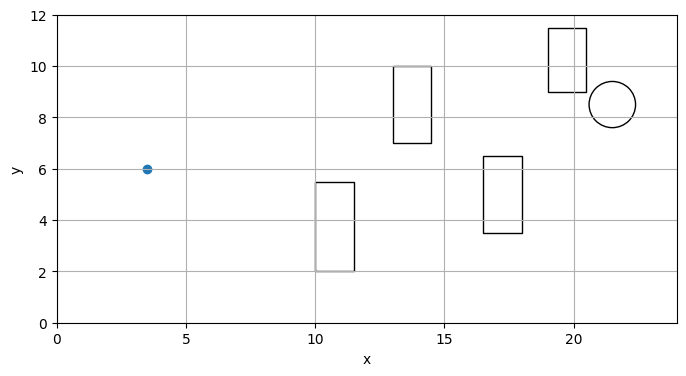

In [ ]:
def plot_env_layout(env):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_xlim(env.x_min, env.x_max)
    ax.set_ylim(env.y_min, env.y_max)

    for (x0, y0, x1, y1) in env.obstacles:
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))

    ax.add_patch(plt.Circle((env.station_cx, env.station_cy), env.station_r, fill=False))
    ax.scatter([env.start_mu[0]], [env.start_mu[1]])

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    plt.show()

env = DroneNavEnvV1(seed=10)
plot_env_layout(env)

# Классы трёх агентов

In [ ]:
class RationalQLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.05, gamma=0.99):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.Q = np.zeros((n_states, n_actions), dtype=np.float64)

    # выбирает действие в состоянии s
    # s   — текущее дискретное состояние
    #eps — вероятность случайного действия
    #rng — генератор случайных чисел
    # иногда агент должен пробовать случайные действия, чтобы изучить среду.
    def select_action(self, s, eps, rng):
        if rng.random() < eps:
            return int(rng.integers(0, self.n_actions))

        row = self.Q[s]
        max_q = np.max(row)
        #ищутся все действия, у которых значение равно максимальному:
        #np.isclose(row, max_q) проверяет, какие значения почти равны максимуму.
        # np.flatnonzero(...) возвращает индексы этих действий.
        best_actions = np.flatnonzero(np.isclose(row, max_q))
        # Агент случайно выбирает одно из лучших действий
        return int(rng.choice(best_actions))

    # обновляет Q-значение после одного перехода
    # s       — старое состояние
    #a       — выбранное действие
    #r       — полученная награда
    #s_next  — новое состояние
    #done    — завершился ли эпизод
    def update(self, s, a, r, s_next, done):
        if done: # Если эпизод завершился, будущих наград уже нет
            target = r
        else:
            # Если эпизод не завершился, агент учитывает: текущую награду r; лучшую ожидаемую будущую награду из следующего состояния.
            target = r + self.gamma * np.max(self.Q[s_next])
        # Q увеличивается, если таргерт больше предыдущего - агент будет считать это действие более полезным
        self.Q[s, a] += self.alpha * (target - self.Q[s, a]) # target - Q[s, a] это ошибка


class ProspectQLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.05, gamma=0.99,
                 a_p=0.88, b_p=0.88, lam_p=2.35):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.a_p = a_p
        self.b_p = b_p
        self.lam_p = lam_p
        self.Q = np.zeros((n_states, n_actions), dtype=np.float64)

    def v(self, r):
        if r >= 0.0:
            return r ** self.a_p
        return -self.lam_p * ((-r) ** self.b_p)

    def select_action(self, s, eps, rng):
        if rng.random() < eps:
            return int(rng.integers(0, self.n_actions))

        row = self.Q[s]
        max_q = np.max(row)
        best_actions = np.flatnonzero(np.isclose(row, max_q))
        return int(rng.choice(best_actions))

    def update(self, s, a, r, s_next, done):
        rr = self.v(r)

        if done:
            target = rr
        else:
            target = rr + self.gamma * np.max(self.Q[s_next])

        self.Q[s, a] += self.alpha * (target - self.Q[s, a])


class RiskSensitiveQLearningAgent:
    def __init__(self, n_states, n_actions, eta=0.5, alpha=0.1, gamma=0.99, reward_scale=100.0):
        if eta not in [0.5, 1.0, 2.0]:
            raise ValueError("eta должен быть одним из значений: 0.5, 1.0, 2.0")

        self.n_states = n_states
        self.n_actions = n_actions
        self.eta = eta
        self.alpha = alpha
        self.gamma = gamma
        self.reward_scale = reward_scale

        self.logU = np.zeros((n_states, n_actions), dtype=np.float64)
        self.Q = np.zeros((n_states, n_actions), dtype=np.float64)

    def select_action(self, s, eps, rng):
        if rng.random() < eps:
            return int(rng.integers(0, self.n_actions))

        row = self.Q[s]
        max_q = np.max(row)
        best_actions = np.flatnonzero(np.isclose(row, max_q))
        return int(rng.choice(best_actions))

    def update(self, s, a, r, s_next, done):
        r_scaled = r / self.reward_scale

        if done:
            min_log_u_next = 0.0
        else:
            min_log_u_next = float(np.min(self.logU[s_next]))

        log_y = -self.eta * r_scaled + self.gamma * min_log_u_next

        old_log_u = self.logU[s, a]

        log_part_old = math.log(1.0 - self.alpha) + old_log_u
        log_part_new = math.log(self.alpha) + log_y

        new_log_u = np.logaddexp(log_part_old, log_part_new)

        self.logU[s, a] = new_log_u
        self.Q[s, a] = -(1.0 / self.eta) * new_log_u

# Обучение каждого агента

In [ ]:
def train_agent(env, agent, episodes=15000, eps0=1.0, eps_min=0.01, eps_decay=0.997, seed=123):
    rng = np.random.default_rng(seed)
    eps = eps0

    rewards = np.zeros(episodes, dtype=np.float64)
    lengths = np.zeros(episodes, dtype=np.int32)
    collisions = np.zeros(episodes, dtype=np.int32)
    final_b = np.zeros(episodes, dtype=np.float64)
    successes = np.zeros(episodes, dtype=np.int32)
    entered_station = np.zeros(episodes, dtype=np.int32)
    min_dists = np.zeros(episodes, dtype=np.float64)

    for ep in range(episodes):
        s = env.reset()
        done = False

        total_r = 0.0
        col = 0
        success = 0
        ever_in_station = False
        min_dist = float("inf")
        steps = 0

        while not done:
            a = agent.select_action(s, eps, rng)
            s_next, r, done, info = env.step(a)
            agent.update(s, a, r, s_next, done)

            total_r += r
            steps += 1

            if info["collision"]:
                col += 1
            if info["success"]:
                success = 1
            if info["in_station"]:
                ever_in_station = True

            dx = info["x"] - env.station_cx
            dy = info["y"] - env.station_cy
            dist = math.sqrt(dx * dx + dy * dy)
            if dist < min_dist:
                min_dist = dist

            s = s_next

        rewards[ep] = total_r
        lengths[ep] = steps
        collisions[ep] = col
        final_b[ep] = info["b"]
        successes[ep] = success
        entered_station[ep] = int(ever_in_station)
        min_dists[ep] = min_dist

        eps = max(eps_min, eps * eps_decay)

    return {
        "rewards": rewards,
        "lengths": lengths,
        "collisions": collisions,
        "final_b": final_b,
        "successes": successes,
        "entered_station": entered_station,
        "min_dists": min_dists,
    }

# Тестирование

In [ ]:
def welch_ttest(a, b):
    a = np.array(a, dtype=np.float64)
    b = np.array(b, dtype=np.float64)
    if len(a) < 2 or len(b) < 2:
        return float("nan"), float("nan")
    t, p = ttest_ind(a, b, equal_var=False)
    return float(t), float(p)

In [ ]:
def run_episode(env, agent, eps, rng, record_traj=False):
    s = env.reset()
    done = False
    total_r = 0.0
    col = 0
    steps = 0
    success = False

    ever_in_station = False
    min_dist = float("inf")

    traj = []
    if record_traj:
        traj.append((env.x, env.y, env.b))

    while not done:
        a = agent.select_action(s, eps, rng)
        s_next, r, done, info = env.step(a)

        total_r += r
        steps += 1

        if info["collision"]:
            col += 1
        success = info["success"]

        dx = info["x"] - env.station_cx
        dy = info["y"] - env.station_cy
        dist = math.sqrt(dx * dx + dy * dy)
        if dist < min_dist:
            min_dist = dist

        if info["in_station"]:
            ever_in_station = True

        s = s_next

        if record_traj:
            traj.append((info["x"], info["y"], info["b"]))

    energy_spent = 1.0 - info["b"]

    return {
        "total_reward": total_r,
        "steps": steps,
        "collisions": col,
        "had_collision": (col > 0),
        "success": success,
        "final_b": info["b"],
        "energy_spent": energy_spent,
        "final_bins": info["bins"],
        "ever_in_station": ever_in_station,
        "min_dist": min_dist,
        "traj": traj,
    }


def evaluate_agent(env_seed, agent, n_episodes=300, eps=0.005, seed=999):
    env = DroneNavEnvV1(seed=env_seed)
    rng = np.random.default_rng(seed)

    results = []
    for _ in range(n_episodes):
        results.append(run_episode(env, agent, eps, rng, record_traj=False))

    success_flags = np.array([r["success"] for r in results], dtype=np.int32)
    steps_arr = np.array([r["steps"] for r in results], dtype=np.float64)
    energy_arr = np.array([r["energy_spent"] for r in results], dtype=np.float64)
    had_col = np.array([r["had_collision"] for r in results], dtype=np.int32)

    entered_station = np.array([r["ever_in_station"] for r in results], dtype=np.int32)
    min_dist_arr = np.array([r["min_dist"] for r in results], dtype=np.float64)

    success_rate = 100.0 * float(np.mean(success_flags))
    collision_rate = 100.0 * float(np.mean(had_col))
    mean_energy = float(np.mean(energy_arr))

    enter_station_rate = 100.0 * float(np.mean(entered_station))
    mean_min_dist = float(np.mean(min_dist_arr))

    success_steps = steps_arr[success_flags == 1]
    mean_time_success = float(np.mean(success_steps)) if len(success_steps) > 0 else float("nan")

    return {
        "results": results,
        "success_rate": success_rate,
        "collision_rate": collision_rate,
        "mean_time_success": mean_time_success,
        "mean_energy": mean_energy,
        "success_steps": success_steps,
        "enter_station_rate": enter_station_rate,
        "mean_min_dist": mean_min_dist,
        "energy_arr": energy_arr
    }

## learning curve

In [ ]:
def moving_average(x, window=150):
    if len(x) < window:
        return x
    w = np.ones(window) / window
    return np.convolve(x, w, mode="valid")

# CDF

In [ ]:
def plot_cdf(data, label):
    data = np.array(data, dtype=np.float64)
    if len(data) == 0:
        return
    data = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    plt.plot(data, y, label=label)

# Heatmap

In [ ]:
def heatmap_final_b(env, eval_pack, title):
    sums = np.zeros((env.n_dx, env.n_dy), dtype=np.float64)
    counts = np.zeros((env.n_dx, env.n_dy), dtype=np.int32)

    for r in eval_pack["results"]:
        dx_bin, dy_bin, _, _ = r["final_bins"]
        sums[dx_bin, dy_bin] += r["final_b"]
        counts[dx_bin, dy_bin] += 1

    mean_b = np.zeros_like(sums)
    mask = counts > 0
    mean_b[mask] = sums[mask] / counts[mask]

    plt.figure(figsize=(6, 5))
    plt.imshow(mean_b.T, origin="lower", aspect="auto")
    plt.colorbar(label="Средний финальный заряд b")
    plt.title(title)
    plt.xlabel("dx-bin")
    plt.ylabel("dy-bin")
    plt.show()

# Траектории

In [ ]:
def collect_trajectories(agent, env_seed, n_traj=4, eps=0.005, seed=2024):
    env = DroneNavEnvV1(seed=env_seed)
    rng = np.random.default_rng(seed)
    trajs = []
    for _ in range(n_traj):
        out = run_episode(env, agent, eps, rng, record_traj=True)
        trajs.append(out["traj"])
    return env, trajs

def plot_trajectories(env, trajs, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_xlim(env.x_min, env.x_max)
    ax.set_ylim(env.y_min, env.y_max)

    for (x0, y0, x1, y1) in env.obstacles:
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))

    ax.add_patch(plt.Circle((env.station_cx, env.station_cy), env.station_r, fill=False))

    for traj in trajs:
        xs = [p[0] for p in traj]
        ys = [p[1] for p in traj]
        ax.plot(xs, ys)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    plt.show()

# Настройки

In [ ]:
TRAIN_EPISODES = 35000
TEST_EPISODES = 300
ALPHA = 0.4
GAMMA = 0.99

TRAIN_ENV_SEED = 0
TRAIN_POLICY_SEED = 1

TEST_ENV_SEED = 2
TEST_POLICY_SEED = 3

TRAJ_ENV_SEED = 4
TRAJ_POLICY_SEED = 5

60000 и alpha=0.1 рациональный обучался
90000 и alpha=0.1 поведенческий обучался
27к и alpha = 0.3 рациональный обучался отлично
25к и 0.4 рациональный

# Рациональный

In [ ]:
env_rational = DroneNavEnvV1(seed=TRAIN_ENV_SEED)

agent_rational = RationalQLearningAgent(env_rational.n_states, env_rational.n_actions, alpha=ALPHA, gamma=GAMMA)

log_rational = train_agent(env_rational, agent_rational, episodes=15000, seed=TRAIN_POLICY_SEED)

In [ ]:
eval_rational = evaluate_agent(env_seed=TEST_ENV_SEED, agent=agent_rational, n_episodes=TEST_EPISODES, eps=0.005, seed=TEST_POLICY_SEED)
print("Рациональный:", eval_rational["success_rate"], "% успех,",
      "время успеха =", eval_rational["mean_time_success"],
      "энергия =", eval_rational["mean_energy"],
      "коллизии =", eval_rational["collision_rate"], "% эпизодов,",
      "заход в станцию =", eval_rational["enter_station_rate"], "%,",
      "ср. мин. дистанция =", eval_rational["mean_min_dist"])

Рациональный: 0.0 % успех, время успеха = nan энергия = 0.5355551689882483 коллизии = 49.0 % эпизодов, заход в станцию = 9.666666666666666 %, ср. мин. дистанция = 9.940112116291122


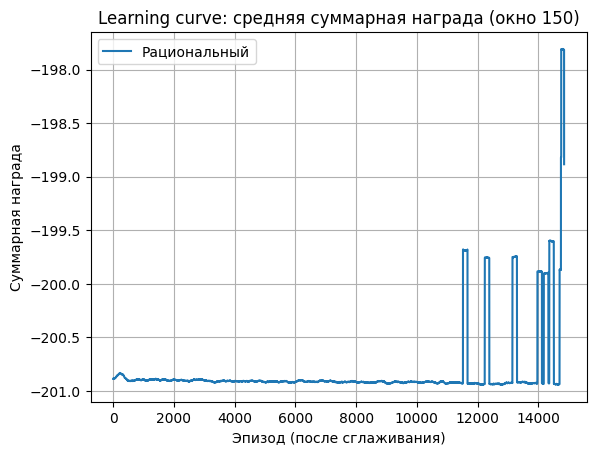

In [ ]:
plt.plot(moving_average(log_rational["rewards"], 150), label="Рациональный")
plt.title("Learning curve: средняя суммарная награда (окно 150)")
plt.xlabel("Эпизод (после сглаживания)")
plt.ylabel("Суммарная награда")
plt.grid(True)
plt.legend()
plt.show()

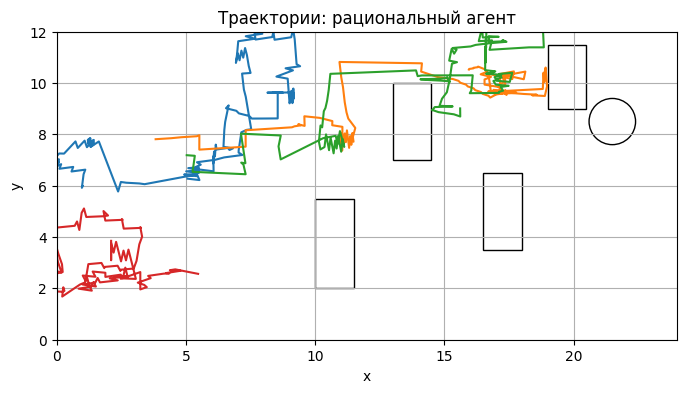

In [ ]:
env_r, trajs_r = collect_trajectories(agent_rational,env_seed=TRAJ_ENV_SEED, n_traj=4, eps=0.005,seed=TRAJ_POLICY_SEED)
plot_trajectories(env_r, trajs_r, "Траектории: рациональный агент")

/tmp/ipykernel_3711/3908398629.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


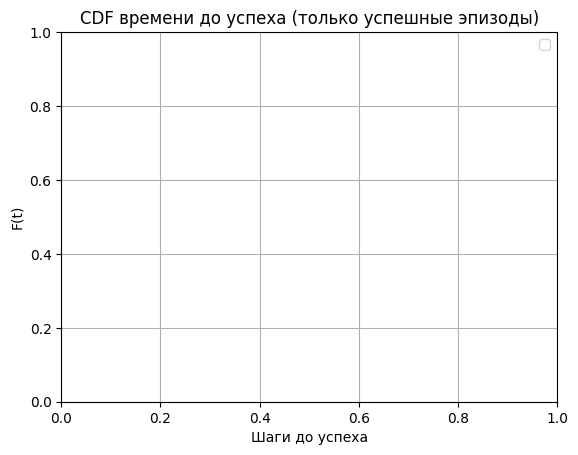

In [ ]:
plot_cdf(eval_rational["success_steps"], "Рациональный")
plt.title("CDF времени до успеха (только успешные эпизоды)")
plt.xlabel("Шаги до успеха")
plt.ylabel("F(t)")
plt.grid(True)
plt.legend()
plt.show()

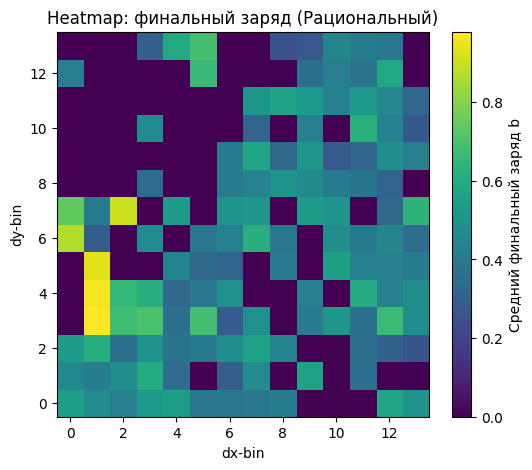

In [ ]:
heatmap_final_b(env_rational, eval_rational, "Heatmap: финальный заряд (Рациональный)")

# Поведенческий

In [ ]:
env_prospect = DroneNavEnvV1(seed=TRAIN_ENV_SEED)
agent_prospect = ProspectQLearningAgent(env_prospect.n_states, env_prospect.n_actions, alpha=ALPHA, gamma=GAMMA, a_p=0.88, b_p=0.88, lam_p=2.35)
log_prospect = train_agent(env_prospect, agent_prospect, episodes=15000, seed=TRAIN_POLICY_SEED)

In [ ]:
eval_prospect = evaluate_agent(env_seed=TEST_ENV_SEED, agent=agent_prospect, n_episodes=TEST_EPISODES, eps=0.005, seed=TEST_POLICY_SEED)
print("Поведенческий:", eval_prospect["success_rate"], "% успех,",
      "время успеха =", eval_prospect["mean_time_success"],
      "энергия =", eval_prospect["mean_energy"],
      "коллизии =", eval_prospect["collision_rate"], "% эпизодов,",
      "заход в станцию =", eval_prospect["enter_station_rate"], "%,",
      "ср. мин. дистанция =", eval_prospect["mean_min_dist"])

Поведенческий: 0.0 % успех, время успеха = nan энергия = 0.5922653594338484 коллизии = 44.333333333333336 % эпизодов, заход в станцию = 2.666666666666667 %, ср. мин. дистанция = 9.701350056292124


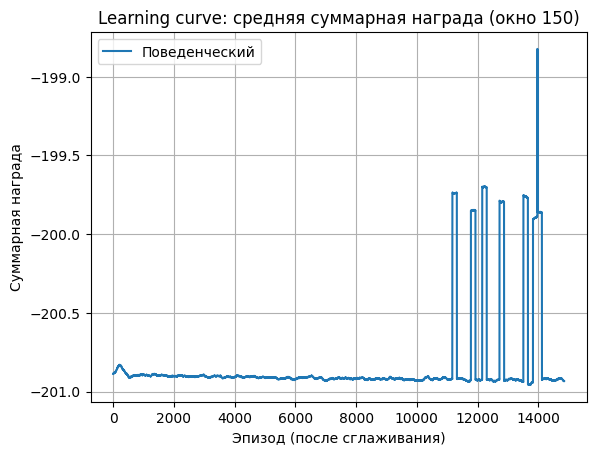

In [ ]:
plt.plot(moving_average(log_prospect["rewards"], 150), label="Поведенческий")
plt.title("Learning curve: средняя суммарная награда (окно 150)")
plt.xlabel("Эпизод (после сглаживания)")
plt.ylabel("Суммарная награда")
plt.grid(True)
plt.legend()
plt.show()

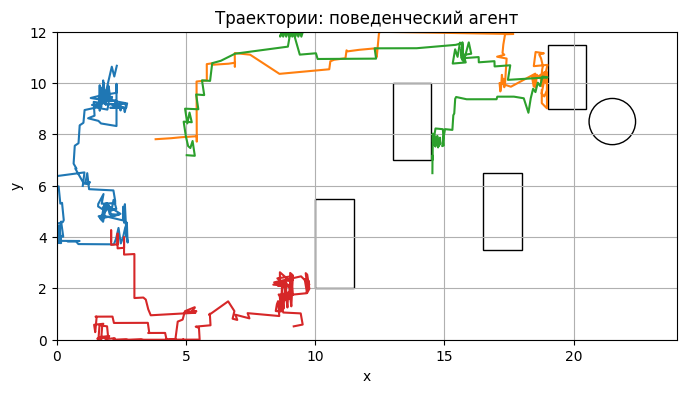

In [ ]:
env_p, trajs_p = collect_trajectories(agent_prospect, env_seed=TRAJ_ENV_SEED, n_traj=4, eps=0.005,seed=TRAJ_POLICY_SEED)
plot_trajectories(env_p, trajs_p, "Траектории: поведенческий агент")

/tmp/ipykernel_3711/934704690.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


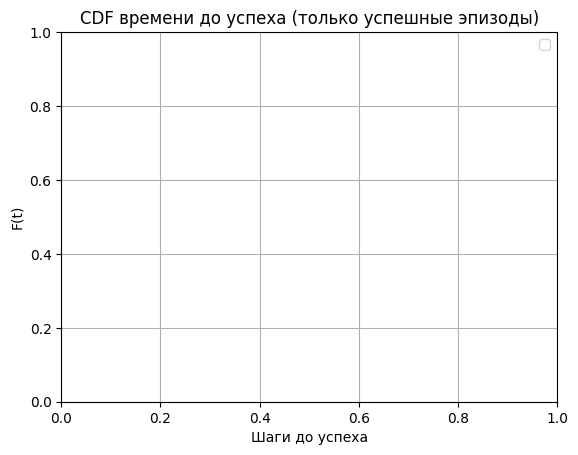

In [ ]:
plot_cdf(eval_prospect["success_steps"], "Поведенческий")
plt.title("CDF времени до успеха (только успешные эпизоды)")
plt.xlabel("Шаги до успеха")
plt.ylabel("F(t)")
plt.grid(True)
plt.legend()
plt.show()

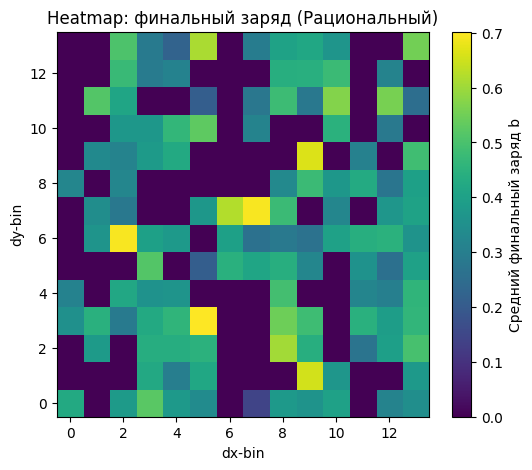

In [ ]:
heatmap_final_b(env_prospect, eval_prospect, "Heatmap: финальный заряд (Рациональный)")

# Риск

In [ ]:
env_risk = DroneNavEnvV1(seed=TRAIN_ENV_SEED)
agent_risk = RiskSensitiveQLearningAgent(env_risk.n_states, env_risk.n_actions,eta=2, alpha=ALPHA, gamma=GAMMA)
log_risk = train_agent(env_risk, agent_risk, episodes=35000, seed=TRAIN_POLICY_SEED)

In [ ]:
eval_risk = evaluate_agent(env_seed=TEST_ENV_SEED, agent=agent_risk, n_episodes=TEST_EPISODES, eps=0.005, seed=TEST_POLICY_SEED)
print("Риск-чувствительный:", eval_risk["success_rate"], "% успех,",
      "время успеха =", eval_risk["mean_time_success"],
      "энергия =", eval_risk["mean_energy"],
      "коллизии =", eval_risk["collision_rate"], "% эпизодов,",
      "заход в станцию =", eval_risk["enter_station_rate"], "%,",
      "ср. мин. дистанция =", eval_risk["mean_min_dist"])

Риск-чувствительный: 98.33333333333333 % успех, время успеха = 67.24406779661017 энергия = 0.09685898525495555 коллизии = 34.0 % эпизодов, заход в станцию = 98.66666666666667 %, ср. мин. дистанция = 0.43125937849777973


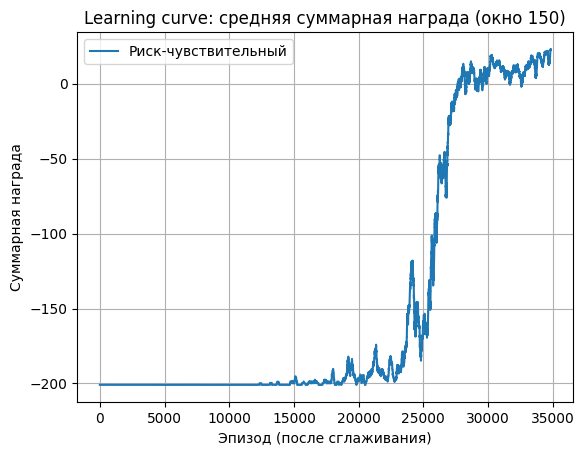

In [ ]:
plt.plot(moving_average(log_risk["rewards"], 150), label="Риск-чувствительный")
plt.title("Learning curve: средняя суммарная награда (окно 150)")
plt.xlabel("Эпизод (после сглаживания)")
plt.ylabel("Суммарная награда")
plt.grid(True)
plt.legend()
plt.show()

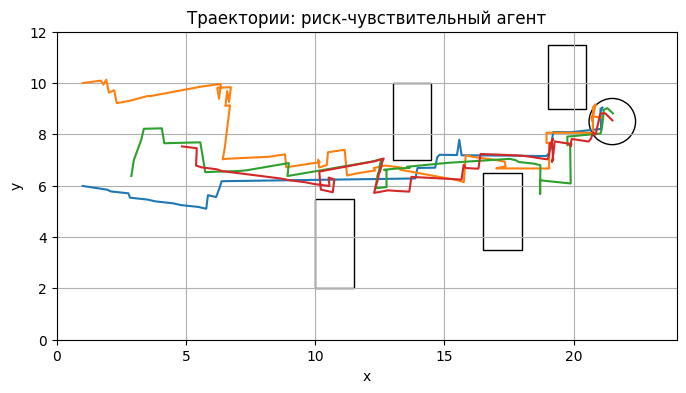

In [ ]:
env_s, trajs_s = collect_trajectories(agent_risk, env_seed=TRAJ_ENV_SEED, n_traj=4, eps=0.005,seed=TRAJ_POLICY_SEED)
plot_trajectories(env_s, trajs_s, "Траектории: риск-чувствительный агент")

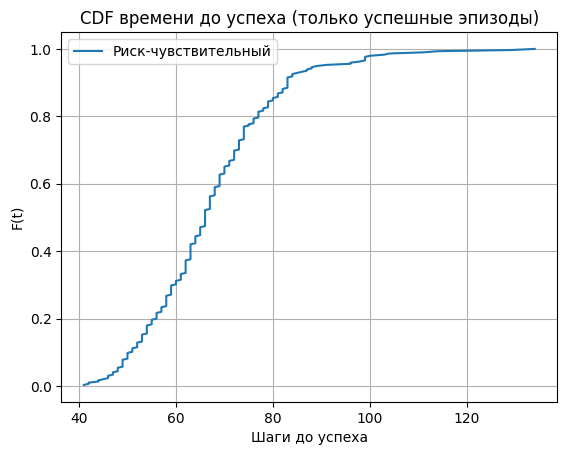

In [ ]:
plot_cdf(eval_risk["success_steps"], "Риск-чувствительный")
plt.title("CDF времени до успеха (только успешные эпизоды)")
plt.xlabel("Шаги до успеха")
plt.ylabel("F(t)")
plt.grid(True)
plt.legend()
plt.show()

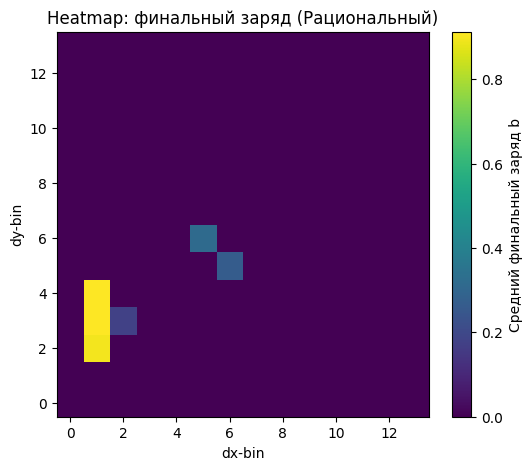

In [ ]:
heatmap_final_b(env_risk, eval_risk, "Heatmap: финальный заряд (Рациональный)")

# Общий learning curve

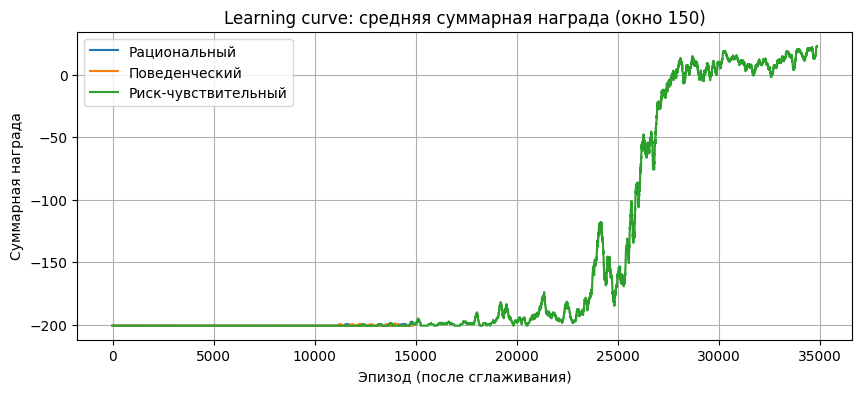

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(moving_average(log_rational["rewards"], 150), label="Рациональный")
plt.plot(moving_average(log_prospect["rewards"], 150), label="Поведенческий")
plt.plot(moving_average(log_risk["rewards"], 150), label="Риск-чувствительный")
plt.title("Learning curve: средняя суммарная награда (окно 150)")
plt.xlabel("Эпизод (после сглаживания)")
plt.ylabel("Суммарная награда")
plt.grid(True)
plt.legend()
plt.show()

# Общий CDF

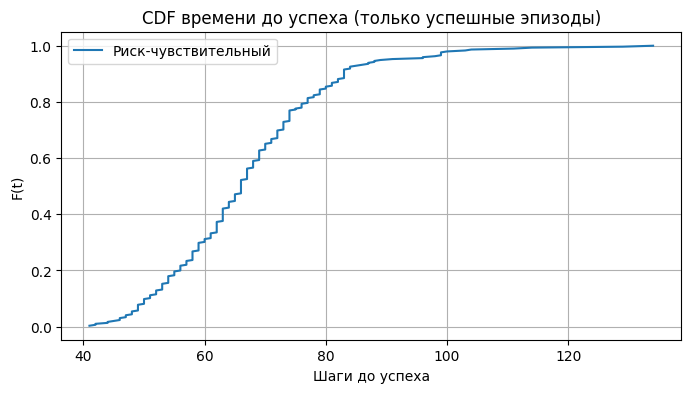

In [ ]:
plt.figure(figsize=(8, 4))
plot_cdf(eval_rational["success_steps"], "Рациональный")
plot_cdf(eval_prospect["success_steps"], "Поведенческий")
plot_cdf(eval_risk["success_steps"], "Риск-чувствительный")
plt.title("CDF времени до успеха (только успешные эпизоды)")
plt.xlabel("Шаги до успеха")
plt.ylabel("F(t)")
plt.grid(True)
plt.legend()
plt.show()

# Статистика t-test

In [ ]:
pairs = [
    ("Рациональный vs Поведенческий", eval_rational["energy_arr"], eval_prospect["energy_arr"]),
    ("Рациональный vs Риск-чувствительный", eval_rational["energy_arr"], eval_risk["energy_arr"]),
    ("Поведенческий vs Риск-чувствительный", eval_prospect["energy_arr"], eval_risk["energy_arr"]),
]

for name, a, b in pairs:
    t, p = welch_ttest(a, b)
    print(name, "| t =", t, "| p =", p)

Рациональный vs Поведенческий | t = -5.441033858748601 | p = 7.836816198755507e-08
Рациональный vs Риск-чувствительный | t = 47.88111533493 | p = 1.4576277487284225e-181
Поведенческий vs Риск-чувствительный | t = 62.20538333935561 | p = 7.709074058125187e-243
